In [1]:

# Step 0: imports and configuration
import sys
sys.path.insert(0, '/home1/jek/custom_pkg')
from tool.ty_pkg import tc_finder, latlon_extent

import subprocess, shutil
import xarray as xr
import numpy as np
import tempfile
from pathlib import Path
import dask.array as da
from datetime import datetime, timedelta
from joblib import Parallel, delayed
from scipy.ndimage import minimum_filter, maximum_filter, label

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from sklearn.decomposition import PCA
import pickle

G = 9.80665  # 표준 중력 가속도
MAX_MEMBERS = 51
DATETIME = "2022082700"

# ─── tc_finder parameters (identical to reference notebook) ───
init_size        = 3        # degrees, search window around seed position
mask_size        = 4        # degrees, search radius for subsequent timesteps
mslp_z_dis       = 300      # km, max distance between MSLP min and Z300-Z500 max
mslp_z_dis_td    = 300      # km, TD-specific distance threshold
wind_thres       = 5        # m/s, minimum wind speed
vort_thres       = 5e-05    # s^-1, minimum vorticity
wind_vort_field  = 300      # km, radius for wind/vort field check
local_min_size   = 5        # degrees, window size for local minimum
patience         = 2        # timesteps, patience if TC not found
retro_opt        = 'td'     # retrograde option: strong systems only
start_track_time = 24       # hours, forward tracking starts at T+24h

# ─── Predict interval list: 12h, 24h, ..., 120h ───
predict_interval_list = np.arange(0, 121, 6)   # [12, 24, ..., 120]

T0 = datetime(2022, 8, 27, 0, 0)

# ─── IBTrACS best-track data (Hinnamnor 2022) ───
_bt = xr.open_dataset('/home1/jek/Pangu-Weather/input_data/IBTrACS.WP.v04r01.nc')
_bt_tc = _bt.where(_bt['season'] == 2022, drop=True)
_bt_tc['name_str'] = _bt_tc['name'].str.decode('utf-8').str.strip()
_bt_tc = _bt_tc.where(_bt_tc['name_str'].str.upper() == 'HINNAMNOR', drop=True)
storm_lat  = _bt_tc['usa_lat'][0].values.astype(np.float32)
storm_lon  = _bt_tc['usa_lon'][0].values.astype(np.float32)
storm_mslp = _bt_tc['usa_pres'][0].values.astype(np.float32)
storm_time = _bt_tc['iso_time'][0].values.astype('datetime64').astype(datetime)
_bt.close()

# fix negative longitudes
storm_lon = np.where(storm_lon < 0, storm_lon + 360, storm_lon)

_idx_mask = ~np.isnan(storm_lon)
storm_lat, storm_lon, storm_mslp, storm_time = (
    storm_lat[_idx_mask], storm_lon[_idx_mask],
    storm_mslp[_idx_mask], storm_time[_idx_mask]
)

# ─── Domain (same as reference notebook for Hinnamnor 2022-08-27) ───
lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = \
    latlon_extent(100, 160, 5, 45)
lon_grid, lat_grid = np.meshgrid(
    lon_indices[lon_start:lon_end + 1],
    lat_indices[lat_start:lat_end + 1]
)
print(f"Domain: lon {lon_indices[lon_start]:.2f}–{lon_indices[lon_end]:.2f}, "
      f"lat {lat_indices[lat_start]:.2f}–{lat_indices[lat_end]:.2f}")
print(f"Grid shape: {lat_grid.shape}")
print(f"Best-track entries loaded: {len(storm_time)}")
print(f"T+0h best-track position: lat={storm_lat[storm_time==T0][0]:.2f}, "
      f"lon={storm_lon[storm_time==T0][0]:.2f}")


Domain: lon 100.00–160.00, lat 45.00–5.00
Grid shape: (161, 241)
Best-track entries loaded: 85
T+0h best-track position: lat=21.70, lon=150.10


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# tc_finder data wrapper — reads TIGGE xarray Dataset slices
# ─────────────────────────────────────────────────────────────────────────────
# TIGGE grid: latitude 90→-90 (descending), longitude 0→359.75
# tc_finder / latlon_extent uses lat: high→low (descending) — no flip needed


def _extract_domain(data_2d, ds_lat, ds_lon,
                    lat_indices, lon_indices,
                    lat_start, lat_end, lon_start, lon_end):
    """
    Slice a 2D (lat, lon) numpy array to the tc_finder domain.

    TIGGE latitude is already descending (90→-90), matching lat_indices
    from latlon_extent. No axis flip required.

    Parameters
    ----------
    data_2d : np.ndarray  shape (n_lat, n_lon)
    ds_lat   : 1-D array of TIGGE latitude values (descending, 90→-90)
    ds_lon   : 1-D array of TIGGE longitude values (0→359.75)

    Returns
    -------
    2-D array with shape matching lat_grid / lon_grid
    """
    target_lat = lat_indices[lat_start:lat_end + 1]   # descending (high→low)
    target_lon = lon_indices[lon_start:lon_end + 1]    # ascending

    lat_hi, lat_lo = target_lat[0], target_lat[-1]     # e.g. 45, 5
    lat_mask = (ds_lat >= lat_lo - 0.01) & (ds_lat <= lat_hi + 0.01)
    lat_i0 = np.where(lat_mask)[0][0]
    lat_i1 = np.where(lat_mask)[0][-1] + 1

    lon_hi, lon_lo = target_lon[-1], target_lon[0]     # e.g. 160, 100
    lon_mask = (ds_lon >= lon_lo - 0.01) & (ds_lon <= lon_hi + 0.01)
    lon_i0 = np.where(lon_mask)[0][0]
    lon_i1 = np.where(lon_mask)[0][-1] + 1

    return data_2d[lat_i0:lat_i1, lon_i0:lon_i1]


def get_tc_fields(ds_z, ds_u, ds_v, step_idx,
                  ds_lat, ds_lon,
                  lat_indices, lon_indices,
                  lat_start, lat_end, lon_start, lon_end):
    """
    Extract tc_finder inputs from a single-member, single-time TIGGE slice.

    Parameters
    ----------
    ds_z     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    ds_u     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    ds_v     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    step_idx : int   index into step dim  (T+0h→0, T+6h→1, T+24h→4, ...)

    Returns
    -------
    Z850     : 2-D array (gpm)   — primary field for tc_finder
    z_diff   : 2-D array (gpm)   — Z300 − Z500  (warm-core proxy)
    wind_spd : 2-D array (m/s)   — 1000 hPa wind speed (surface proxy)
    vort_850 : 2-D array (s⁻¹)  — 850 hPa relative vorticity
    """
    def get_level_2d(ds, varname, lev_hpa):
        arr = ds[varname].isel(step=step_idx).sel(level=lev_hpa).values
        return _extract_domain(arr, ds_lat, ds_lon,
                               lat_indices, lon_indices,
                               lat_start, lat_end, lon_start, lon_end)

    # Z850 in gpm
    Z850  = get_level_2d(ds_z, 'gh', 850)

    # z_diff = Z300 − Z500 (gpm) — warm-core thickness proxy
    Z300  = get_level_2d(ds_z, 'gh', 300)
    Z500  = get_level_2d(ds_z, 'gh', 500)
    z_diff = Z300 - Z500

    # 1000 hPa wind as surface proxy (m/s)
    u1000 = get_level_2d(ds_u, 'u', 1000)
    v1000 = get_level_2d(ds_v, 'v', 1000)
    wind_spd = np.sqrt(u1000**2 + v1000**2)

    # 850 hPa relative vorticity (s⁻¹) — finite-difference on lat/lon grid
    u850 = get_level_2d(ds_u, 'u', 850)
    v850 = get_level_2d(ds_v, 'v', 850)

    deg2rad = np.pi / 180.0
    R = 6371e3  # m
    delta_lon = 0.25 * deg2rad * R * np.cos(lat_grid * deg2rad)
    delta_lat = 0.25 * deg2rad * R

    dv_dx    =  np.gradient(v850, axis=1) / delta_lon
    du_dy    = -np.gradient(u850, axis=0) / delta_lat   # negative: lat descending
    vort_850 = dv_dx - du_dy

    return Z850, z_diff, wind_spd, vort_850


print("Data wrapper functions defined.")

Data wrapper functions defined.


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ds = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_tquv.nc")
ds_z = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_z.nc")
ds_t = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_t.nc")
ds_q = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_q.nc")
ds_u = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_u.nc")
ds_v = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_v.nc")

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# tc_finder tracking — forward + retrograde, per ensemble member
# ─────────────────────────────────────────────────────────────────────────────

# TIGGE file paths (PF: perturbed forecast, 50 members)
Z_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_z.nc"
U_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_u.nc"
V_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_v.nc"
T_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_t.nc"

# CF temperature is in the same tquv file


# CF file paths (control forecast, 1 deterministic run — step is timedelta, has date dim)
CF_Z_PATH  = "/data09/TC/TIGGE/ENS_field_data/ecmf_cf_z.nc"
CF_UV_PATH = "/data09/TC/TIGGE/ENS_field_data/ecmf_cf_tquv.nc"   # u, v inside
CF_T_PATH = CF_UV_PATH
CF_MEMBER_ID = 50  # 0-indexed; CF is the 51st member

# ─── ssv_dict save/load ───────────────────────────────────────────────────────
new_ssv = 'n'   # 'y' = compute fresh; 'n' = load from file
SSV_PKL = f"/data09/TC/TIGGE/ENS_field_data/ECMWF_Track_{T0.strftime('%Y%m%d%H')}.pkl"
# ─────────────────────────────────────────────────────────────────────────────


def _select_member(ds_z_full, ds_u_full, ds_v_full, member_id, T0):
    """
    Return (ds_zm, ds_um, ds_vm, ds_lat, ds_lon) for a given member.

    For PF (member_id 0–49): selects by number coord (1-indexed).
    For CF (member_id == CF_MEMBER_ID): selects by date (T0's date), no number dim.
    ds_u_full / ds_v_full for CF may be the same tquv file.
    """
    ds_lat = ds_z_full['latitude'].values   # descending (90→-90)
    ds_lon = ds_z_full['longitude'].values  # ascending  (0→359.75)
    if member_id == CF_MEMBER_ID:
        date_sel = np.datetime64(T0.date())
        ds_zm = ds_z_full.sel(date=date_sel)
        ds_um = ds_u_full.sel(date=date_sel)
        ds_vm = ds_v_full.sel(date=date_sel)
    else:
        member_num = member_id + 1   # TIGGE number is 1-indexed
        ds_zm = ds_z_full.sel(number=member_num)
        ds_um = ds_u_full.sel(number=member_num)
        ds_vm = ds_v_full.sel(number=member_num)
    return ds_zm, ds_um, ds_vm, ds_lat, ds_lon


def process_single_member(member_id,
                           z_path, u_path, v_path,
                           predict_interval_list, start_track_time,
                           lat_indices, lon_indices,
                           lat_start, lat_end, lon_start, lon_end,
                           lat_grid, lon_grid,
                           storm_lon, storm_lat, storm_mslp, storm_time,
                           T0, retro_opt,
                           init_size, mask_size, local_min_size,
                           mslp_z_dis, mslp_z_dis_td,
                           wind_thres, vort_thres, wind_vort_field, patience):
    """
    Run tc_finder forward + retrograde tracking for one ensemble member.

    member_id 0–49: PF member (number = member_id + 1)
    member_id  50 : CF (control forecast, no number dim, uses date dim)
    """
    ens_min_position = {}
    current_patience = 0

    with xr.open_dataset(z_path) as ds_z_full, \
         xr.open_dataset(u_path) as ds_u_full, \
         xr.open_dataset(v_path) as ds_v_full:

        ds_zm, ds_um, ds_vm, ds_lat, ds_lon = _select_member(
            ds_z_full, ds_u_full, ds_v_full, member_id, T0)

        # ── 1. Forward tracking: start_track_time → end ──────────────────
        for predict_interval in predict_interval_list:
            if predict_interval < start_track_time:
                continue
            pred_time = T0 + timedelta(hours=int(predict_interval))
            step_idx  = int(predict_interval // 6)   # T+0→0, T+6→1, T+24→4, ...

            Z850, z_diff, wind_spd, vort_850 = get_tc_fields(
                ds_zm, ds_um, ds_vm, step_idx,
                ds_lat, ds_lon,
                lat_indices, lon_indices,
                lat_start, lat_end, lon_start, lon_end
            )

            ens_min_position, current_patience = tc_finder(
                Z850, lat_indices, lon_indices,
                lat_start, lon_start, lat_grid, lon_grid,
                z_diff, wind_spd, vort_850,
                pred_time, storm_lon, storm_lat, storm_mslp, storm_time,
                T0, ens_min_position, current_patience,
                mask_size=mask_size, init_size=init_size,
                local_min_size=local_min_size,
                mslp_z_dis=mslp_z_dis,
                wind_thres=wind_thres, vort_thres=vort_thres,
                wind_vort_field=wind_vort_field, patience=patience
            )

        # ── 2. Retrograde tracking: end → start ──────────────────────────
        if retro_opt == 'td':
            for predict_interval in predict_interval_list[::-1]:
                pred_time = T0 + timedelta(hours=int(predict_interval))
                step_idx  = int(predict_interval // 6)

                Z850, z_diff, wind_spd, vort_850 = get_tc_fields(
                    ds_zm, ds_um, ds_vm, step_idx,
                    ds_lat, ds_lon,
                    lat_indices, lon_indices,
                    lat_start, lat_end, lon_start, lon_end
                )

                ens_min_position, current_patience = tc_finder(
                    Z850, lat_indices, lon_indices,
                    lat_start, lon_start, lat_grid, lon_grid,
                    z_diff, wind_spd, vort_850,
                    pred_time, storm_lon, storm_lat, storm_mslp, storm_time,
                    T0, ens_min_position, current_patience,
                    mask_size=mask_size, local_min_size=local_min_size,
                    back_prop='y', mslp_z_dis=mslp_z_dis_td,
                    wind_thres=wind_thres, vort_thres=vort_thres,
                    wind_vort_field=wind_vort_field, patience=patience
                )

    return member_id, {k: ens_min_position[k] for k in sorted(ens_min_position)}


# ── Member list: 50 PF + 1 CF = 51 total ─────────────────────────────────────
pf_member_ids = list(range(50))    # 0–49 → PF number 1–50
all_member_ids = pf_member_ids + [CF_MEMBER_ID]
print(f"Total members to process: {len(all_member_ids)}  (PF={len(pf_member_ids)}, CF=1)")


if new_ssv == 'y':
    # ── PF: Parallel tc_finder tracking ──────────────────────────────────────
    pf_results = Parallel(n_jobs=20, verbose=5)(
        delayed(process_single_member)(
            member_id,
            Z_PATH, U_PATH, V_PATH,
            predict_interval_list, start_track_time,
            lat_indices, lon_indices,
            lat_start, lat_end, lon_start, lon_end,
            lat_grid, lon_grid,
            storm_lon, storm_lat, storm_mslp, storm_time,
            T0, retro_opt,
            init_size, mask_size, local_min_size,
            mslp_z_dis, mslp_z_dis_td,
            wind_thres, vort_thres, wind_vort_field, patience
        )
        for member_id in pf_member_ids
    )

    # ── CF: single member tracking ────────────────────────────────────────────
    cf_result = process_single_member(
        CF_MEMBER_ID,
        CF_Z_PATH, CF_UV_PATH, CF_UV_PATH,   # u and v both in tquv file
        predict_interval_list, start_track_time,
        lat_indices, lon_indices,
        lat_start, lat_end, lon_start, lon_end,
        lat_grid, lon_grid,
        storm_lon, storm_lat, storm_mslp, storm_time,
        T0, retro_opt,
        init_size, mask_size, local_min_size,
        mslp_z_dis, mslp_z_dis_td,
        wind_thres, vort_thres, wind_vort_field, patience
    )

    # ── Aggregate: ssv_dict[T0][member_id] = {datetime: {lon,lat,mslp,type}} ─
    all_results = pf_results + [cf_result]
    ssv_dict = {T0: {mid: pos for mid, pos in all_results}}
    print(f"Tracking complete.  Members with at least one fix: "
          f"{sum(1 for _, pos in all_results if pos)}/{len(all_results)}")

    with open(SSV_PKL, 'wb') as f:
        pickle.dump(ssv_dict, f)
    print(f"Saved ssv_dict to {SSV_PKL}")

else:
    with open(SSV_PKL, 'rb') as f:
        ssv_dict = pickle.load(f)
    print(f"Loaded ssv_dict from {SSV_PKL}")

N_ENS = len(ssv_dict[T0])
print(f"ssv_dict: {N_ENS} members")

Total members to process: 51  (PF=50, CF=1)
Loaded ssv_dict from /data09/TC/TIGGE/ENS_field_data/ECMWF_Track_2022082700.pkl
ssv_dict: 51 members


level: [  50,  200,  250,  300,  500,  700,  850,  925, 1000]

d_level: [ ? , 100, 50, 125, 200, 175, 137.5, 75, ?]

In [53]:
mid_pos = []
for t in range(0, 73, 6):
    snap_time = T0 + timedelta(hours = t)
    tar_pos = []
    for ens, single_data in min_position.items():
        snap_data = min_position[ens].get(T0+timedelta(hours=t), None)
        first_data = min_position[ens].get(T0+timedelta(hours=12), None)
        if snap_data and first_data:
            tar_pos.append([snap_data['lon'], snap_data['lat']])
            if t == 72:
                mid_pos.append([snap_data['lon'], snap_data['lat']])

    if len(tar_pos) <= 1:
        continue
    else:
        tar_pos = np.array(tar_pos)

    snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
    
    # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

    corr_pos_tar = np.copy(tar_pos)
    corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
    pca_tar = PCA(n_components=1)
    pca_tar.fit(corr_pos_tar)
    pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])

# --- PCA 성분 추출 및 보정 ---
v1 = pca_tar.components_[0]  # [dx_corrected, dy]

# 위경도 평면에서 보여질 실제 방향 벡터 (경도 보정 역산)
# dx = dx_corrected / cos_lat
cos_lat = np.cos(np.radians(tar_pos[:, 1].mean()))  # 타겟 위치의 평균 위도에서 cos 계산
v_lon = v1[0] / cos_lat
v_lat = v1[1]

# 화살표의 길이를 결정하는 스케일 (사용자 정의 spread_scale 사용)
# 여기서는 중심으로부터 양쪽으로 spread_scale만큼 뻗어나가게 설정
origin_lon = np.mean(tar_pos[:, 0])
origin_lat = np.mean(tar_pos[:, 1])

{0: 57.8, 6: 54.6, 12: 54.2, 18: 91.1, 24: 74.6, 30: 88.5, 36: 105.0, 42: 127.3, 48: 144.8, 54: 177.2, 60: 216.2, 66: 266.7, 72: 317.2, 78: 406.9, 84: 497.6, 90: 595.9, 96: 719.6, 102: 891.7, 108: 996.3, 114: 1089.0, 120: 1207.1}
{0: 36, 6: 38, 12: 44, 18: 43, 24: 43, 30: 43, 36: 43, 42: 43, 48: 43, 54: 41, 60: 40, 66: 36, 72: 33, 78: 27, 84: 25, 90: 20, 96: 18, 102: 15, 108: 14, 114: 12, 120: 10}
51/51 ensembles predicted the track.


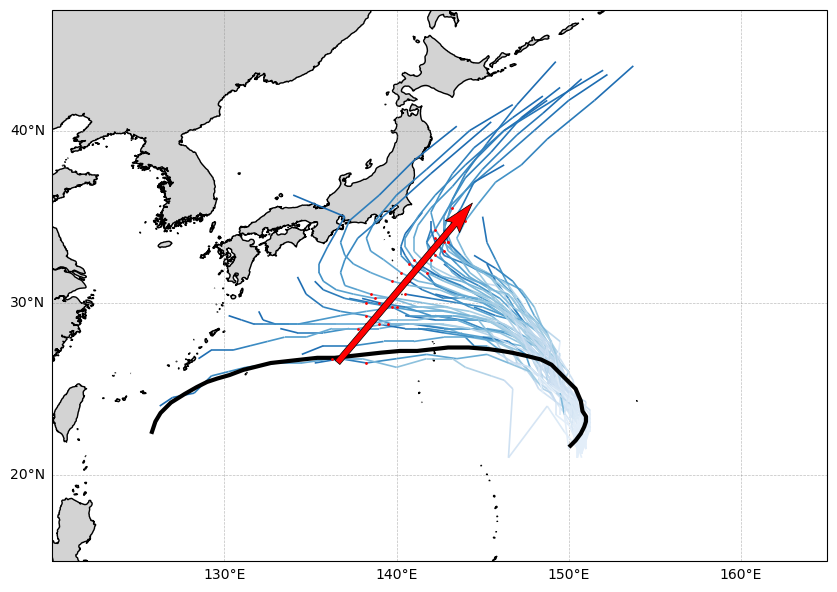

(0.0, 550.0)

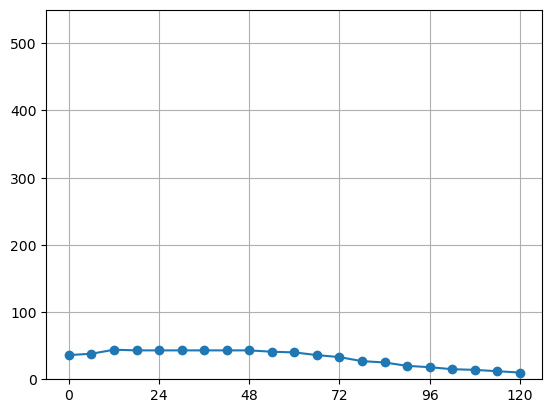

In [54]:
def plot_ens_tracks(lons, lats, ax, cmap, zorder = 0):

    x = np.array(lons)
    y = np.array(lats)

    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    if len(x_clean) < 2:
        return

    points = np.array([x_clean, y_clean]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    t = np.linspace(0, 1, len(x_clean))

    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1), zorder = zorder)
    lc.set_array(t)
    lc.set_linewidth(1.2)

    ax.add_collection(lc)


min_position = ssv_dict[T0]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
plot_extent = [120, 165, 15, 47]
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines("10m")
full_blues = plt.get_cmap('Blues')
new_colors_blue = full_blues(np.linspace(0.1, 0.8, 256))
blue_cmap = mcolors.LinearSegmentedColormap.from_list('Blues_truncated', new_colors_blue)
ax.plot(storm_lon[:41], storm_lat[:41], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=3)

num = 0
for ens in range(MAX_MEMBERS):  
    lons = [pos['lon'] for _,pos in min_position[ens].items()]
    lats = [pos['lat'] for _,pos in min_position[ens].items()]
    plot_ens_tracks(lons, lats, ax, cmap = blue_cmap, zorder = 8)
    # max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
    # pred_times = [pos for pos,_ in min_position[ens].items()]
    num += 1 if len(lons)>0 else 0
    # lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
# cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)
explained_var = pca_tar.explained_variance_[0]
spread_scale  = 1 * np.sqrt(explained_var)*4

ens_spread_dict = {}
ens_error_dict = {}
ens_num_dict = {}

mid_pos = []
for t in range(0, 121, 6):
    snap_time = T0 + timedelta(hours = t)
    tar_pos = []
    for ens, single_data in min_position.items():
        snap_data = min_position[ens].get(T0+timedelta(hours=t), None)
        first_data = min_position[ens].get(T0+timedelta(hours=12), None)
        if snap_data and first_data:
            tar_pos.append([snap_data['lon'], snap_data['lat']])
            if t == 72:
                mid_pos.append([snap_data['lon'], snap_data['lat']])

    if len(tar_pos) <= 1:
        continue
    else:
        tar_pos = np.array(tar_pos)

    snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
    
    # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

    corr_pos_tar = np.copy(tar_pos)
    corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
    pca_tar = PCA(n_components=1)
    pca_tar.fit(corr_pos_tar)
    pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])
    projection = pca_tar.transform(corr_pos_tar)[:, 0]  # 주축에 투영된 데이터 (1차원)
    distances_tar = (projection - np.mean(projection)) * 111
    ens_spread_dict[t] = np.std(distances_tar, ddof = 1).round(1)
    # ens_error_dict[t] = haversine_distance(snap_lon, snap_lat, avg_lon, avg_lat).round(1)
    ens_num_dict[t] = len(distances_tar)

print(ens_spread_dict)
# print(ens_error_dict)
print(ens_num_dict)

ax.scatter(np.array(mid_pos)[:,0], np.array(mid_pos)[:,1], color = 'red', zorder = 12, s=1)

print(f"{num}/{MAX_MEMBERS} ensembles predicted the track.")

ax.quiver(
    origin_lon - v_lon * spread_scale / 2, 
    origin_lat - v_lat * spread_scale / 2, 
    v_lon * spread_scale, 
    v_lat * spread_scale,
    angles='xy', scale_units='xy', scale=1, # 단위계를 데이터 좌표계에 고정
    color='red', width=0.008, headwidth=3, 
    label='Principal Axis', zorder=30, edgecolor='black', linewidth=0.5
)
plt.show()

plt.plot(ens_num_dict.keys(), list(ens_num_dict.values()), marker='o')
plt.grid()
plt.xticks(range(0, 121, 24))
# plt.legend(loc = 'upper right')
plt.ylim(0,550)

# Radius, Height 연산

In [4]:
import numpy as np
import xarray as xr
from datetime import timedelta
import dill as pickle
from collections import defaultdict
from tool.ty_pkg import WindFieldSolver, get_factorized_solver

# ─── 1. 실험 및 검증 조건 설정 ──────────────────────────────────────────────────
# 분석할 시간 (T0+12h 지점의 Steering Wind로 T+12~24h 이동 예측)
ANALYSIS_HOURS = [12] 
MAX_MEMBERS = 51
#! ANALYSIS_HOURS=12, TARGET_HOURS=72로 고정되어 있음 하드코딩 주의!!!!
member_tar = [i for i in range(MAX_MEMBERS) if (ssv_dict[T0][i].get(T0 + timedelta(hours=ANALYSIS_HOURS[0])) is not None) and ssv_dict[T0][i].get(T0 + timedelta(hours=72)) is not None]
# 테스트할 반경 리스트 (km)
radii_list = [100, 150, 200, 250, 300, 350, 400, 500] 

# 테스트할 기압층 리스트 및 가중치 계산용 (단순 평균을 위해 1로 설정하거나 실제 두께 사용)
# 여기서는 steer_pres에 포함된 고도들 중 pres_ranges에 정의된 것들을 선택하여 계산합니다.
steer_pres = [850, 700, 500, 300, 250] 

pres_ranges = {
    850: [850],
    700: [850, 700],
    500: [850, 700, 500],
    300: [850, 700, 500, 300],
    250: [850, 700, 500, 300, 250],
}

# level: [  50,  200,  250,  300,  500,  700,  850,  925, 1000]

# d_level: [ ? , 100, 50, 125, 200, 175, 137.5, 75, ?]

weight_ranges = {
    850: [137.5],
    700: [137.5, 175],
    500: [137.5, 175, 200],
    300: [137.5, 175, 200, 125],
    250: [137.5, 175, 200, 125, 50]
}

# ─── 2. Solver 및 그리드 설정 ──────────────────────────────────────────────────
_poisson_solver = get_factorized_solver(lat_grid, dx=111e3/4, dy=111e3/4)
_deg2rad = np.pi / 180.0
_R_km = 6371.0
_R_m = 6371e3

# 그리드 간격 (Vorticity 계산용)
_delta_lon = 0.25 * _deg2rad * _R_m * np.cos(lat_grid * _deg2rad)
_delta_lat = 0.25 * _deg2rad * _R_m



# ─── 3. 핵심 계산 함수 ────────────────────────────────────────────────────────
def _compute_all_combinations_for_member(member_id, analysis_hour):
    """
    한 멤버에 대해 모든 고도(steer_pres)와 모든 반경(radii_list)의 
    Steering Wind 영역 평균을 계산하여 반환합니다.
    """
    pred_time = T0 + timedelta(hours=analysis_hour)
    member_ssv = ssv_dict[T0].get(member_id, {})
    
    if pred_time not in member_ssv:
        return None

    center_lat = float(member_ssv[pred_time]['lat'])
    center_lon = float(member_ssv[pred_time]['lon'])
    step_idx = analysis_hour // 6

    # 데이터 로드 (파일 경로는 사용자 환경에 맞춰 유지)
    is_cf = (member_id == CF_MEMBER_ID)
    u_path = CF_UV_PATH if is_cf else U_PATH
    v_path = CF_UV_PATH if is_cf else V_PATH

    # 결과 저장용: {lev: {radius: (u, v)}}
    member_results = defaultdict(dict)

    with xr.open_dataset(u_path) as ds_u, xr.open_dataset(v_path) as ds_v:
        ds_lat = ds_u['latitude'].values
        ds_lon = ds_u['longitude'].values
        
        # 멤버 선택
        u_sel = ds_u.sel(date=np.datetime64(T0.date())) if is_cf else ds_u.sel(number=member_id+1)
        v_sel = ds_v.sel(date=np.datetime64(T0.date())) if is_cf else ds_v.sel(number=member_id+1)

        for lev in steer_pres:
            # 1. 고도별 바람장 추출
            u_arr = u_sel['u'].isel(step=step_idx).sel(level=lev).values
            v_arr = v_sel['v'].isel(step=step_idx).sel(level=lev).values

            u_dom = _extract_domain(u_arr, ds_lat, ds_lon, lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)
            v_dom = _extract_domain(v_arr, ds_lat, ds_lon, lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)

            # 2. Vorticity/Divergence 계산 (lat descending 고려)
            dv_dx = np.gradient(v_dom, axis=1) / _delta_lon
            du_dy = -np.gradient(u_dom, axis=0) / _delta_lat
            du_dx = np.gradient(u_dom, axis=1) / _delta_lon
            dv_dy = -np.gradient(v_dom, axis=0) / _delta_lat
            vort, div = dv_dx - du_dy, du_dx + dv_dy

            # 3. 모든 반경에 대해 Solver 실행 및 영역 평균
            for r in radii_list:
                solver = WindFieldSolver(lat_grid, lon_grid, center_lat, center_lon,
                                         vort, div, max_iter=50000, tol=1e-2,
                                         sparse_solver=_poisson_solver, radius=r)
                u_ty, v_ty = solver.solve()
                u_st, v_st = u_dom - u_ty, v_dom - v_ty

                # Haversine Masking
                dlat = (lat_grid - center_lat) * _deg2rad
                dlon = (lon_grid - center_lon) * _deg2rad
                a = np.sin(dlat/2)**2 + np.cos(center_lat * _deg2rad) * np.cos(lat_grid * _deg2rad) * np.sin(dlon/2)**2
                c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
                dist_km = _R_km * c
                
                mask = dist_km <= r
                member_results[lev][r] = (np.nanmean(u_st[mask]), np.nanmean(v_st[mask]))

    return member_results

# ─── 4. 실행 및 결과 집계 ─────────────────────────────────────────────────────
# results_dict[hour][range_name][radius] = {'u': [], 'v': []}
results_dict = {h: defaultdict(lambda: defaultdict(lambda: {'u': [], 'v': []})) for h in ANALYSIS_HOURS}

for h in ANALYSIS_HOURS:
    print(f"--- T+{h}h 분석 시작 ---")
    for m in member_tar:
        m_res = _compute_all_combinations_for_member(m, h)
        if m_res is None: continue

        # 고도 범위별 평균 계산 루틴
        for range_name, levels in pres_ranges.items():
            for r in radii_list:
                # 해당 범위 내 고도들의 (u, v) 수집
                u_list = [m_res[lev][r][0] for lev in levels if lev in m_res]
                v_list = [m_res[lev][r][1] for lev in levels if lev in m_res]
                
                # if u_list:
                results_dict[h][range_name][r]['u'].append(np.average(u_list, weights=weight_ranges[range_name]))
                results_dict[h][range_name][r]['v'].append(np.average(v_list, weights=weight_ranges[range_name]))
        
        if m % 10 == 0: print(f"  Member {m}/{len(member_tar)} processed")



/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


--- T+12h 분석 시작 ---
  Member 10/33 processed
  Member 30/33 processed
  Member 50/33 processed


In [51]:
del_x_list = []
del_y_list = []

len(member_tar)
for mem in member_tar:
    first_lon = ssv_dict[T0][mem][T0 + timedelta(hours=12)]['lon']
    first_lat = ssv_dict[T0][mem][T0 + timedelta(hours=12)]['lat']
    second_lon = ssv_dict[T0][mem][T0 + timedelta(hours=18)]['lon']
    second_lat = ssv_dict[T0][mem][T0 + timedelta(hours=18)]['lat']
    del_lon = second_lon - first_lon
    del_lat = second_lat - first_lat    
    del_x = del_lon * np.cos(np.radians((first_lat + second_lat) / 2)) * 111
    del_y = del_lat * 111
    del_x_list.append(del_x)
    del_y_list.append(del_y)

del_x_array = np.array(del_x_list)
del_y_array = np.array(del_y_list)

Range: 850, Radius: 100km → RMSE: 73.47 km
Range: 850, Radius: 150km → RMSE: 67.13 km
Range: 850, Radius: 200km → RMSE: 65.21 km
Range: 850, Radius: 250km → RMSE: 66.43 km
Range: 850, Radius: 300km → RMSE: 64.24 km
Range: 850, Radius: 350km → RMSE: 62.22 km
Range: 850, Radius: 400km → RMSE: 61.26 km
Range: 850, Radius: 500km → RMSE: 59.85 km
Range: 700, Radius: 100km → RMSE: 58.72 km
Range: 700, Radius: 150km → RMSE: 54.15 km
Range: 700, Radius: 200km → RMSE: 59.24 km
Range: 700, Radius: 250km → RMSE: 63.32 km
Range: 700, Radius: 300km → RMSE: 63.71 km
Range: 700, Radius: 350km → RMSE: 63.62 km
Range: 700, Radius: 400km → RMSE: 64.72 km
Range: 700, Radius: 500km → RMSE: 64.16 km
Range: 500, Radius: 100km → RMSE: 66.55 km
Range: 500, Radius: 150km → RMSE: 55.27 km
Range: 500, Radius: 200km → RMSE: 55.42 km
Range: 500, Radius: 250km → RMSE: 57.17 km
Range: 500, Radius: 300km → RMSE: 57.60 km
Range: 500, Radius: 350km → RMSE: 58.34 km
Range: 500, Radius: 400km → RMSE: 58.85 km
Range: 500,

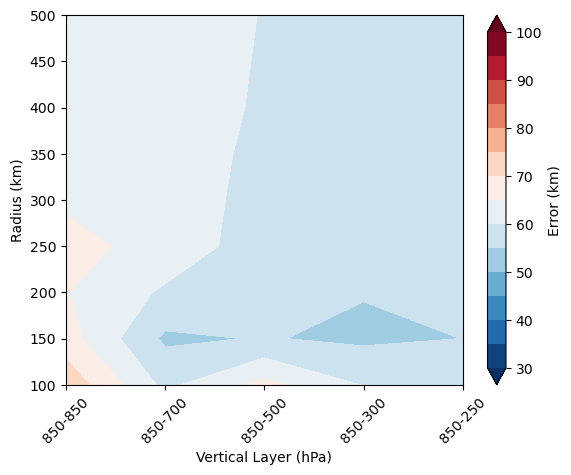

In [64]:
rmse = np.zeros((len(radii_list), len(pres_ranges)))
for i, range_name in enumerate(pres_ranges.keys()):
    for j, r in enumerate(radii_list):
        tc_rm_del_x = np.array(results_dict[12][range_name][r]['u']) * 21.6
        tc_rm_del_y = np.array(results_dict[12][range_name][r]['v']) * 21.6

        rmse[j, i] = np.mean(np.sqrt((del_x_array - tc_rm_del_x)**2 + (del_y_array - tc_rm_del_y)**2))
        print(f"Range: {range_name}, Radius: {r}km → RMSE: {rmse[j, i]:.2f} km")

x_labels = [f"{hpa[0]}-{hpa[-1]}" for hpa in pres_ranges.values()]
# prime_r = radii_list[np.argmin(rmse, axis=0)]  # 각 고도 범위별로 가장 낮은 RMSE를 주는 반경 인덱스
# x_labels[np.argmin(rmse, axis=1)]  # 각 고도 범위별로 가장 낮은 RMSE를 주는 고도 범위 레이블

min_j, min_i = np.unravel_index(np.argmin(rmse), rmse.shape)

best_radius = radii_list[min_j]
best_p_range = x_labels[min_i]
min_rmse_val = rmse[min_j, min_i]

print("-" * 30)
print(f"🏆 최적의 지향류 설정 (Minimum RMSE)")
print(f"📍 고도 범위 (P-layer): {best_p_range} hPa")
print(f"📍 계산 반경 (Radius) : {best_radius} km")
print(f"📉 최소 RMSE 값      : {min_rmse_val:.2f} km")
print("-" * 30)

plt.contourf(x_labels, radii_list, rmse, levels = np.arange(30, 101, 5), cmap='RdBu_r', extend = 'both')
plt.xlabel('Vertical Layer (hPa)')
plt.xticks(rotation=45)
plt.ylabel('Radius (km)')
plt.colorbar(label='Error (km)')
plt.show()


# 실제 Steering Wind 구하기

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TC-Removed Steering Wind Computation
# ─────────────────────────────────────────────────────────────────────────────
from tool.ty_pkg import WindFieldSolver, get_factorized_solver

# ── Parameters ────────────────────────────────────────────────────────────────
START_HOUR     = 12                           # ESA start hour: keep members tracked from T+START_HOUR
TARGET_HOUR    = 72                           # ESA target forecast hour
STEER_LEVELS   = [850, 700, 500]         # hPa (600/400 not in TIGGE)
tc_radius = 250
STEER_DP       = np.array([112.5,175,200])   # layer thickness weights (sum=450)
ANALYSIS_HOURS = [0,6,12, 18, 24]             # analysis times for ESA
# Pre-factorize Poisson solver on the tc_finder domain grid (0.25° resolution)
_poisson_solver = get_factorized_solver(lat_grid, dx=111e3/4, dy=111e3/4)

# Grid spacing for vorticity/divergence computation on domain (lat descending)
_deg2rad  = np.pi / 180.0
_R        = 6371e3
_delta_lon = 0.25 * _deg2rad * _R * np.cos(lat_grid * _deg2rad)  # (n_lat, n_lon)
_delta_lat = 0.25 * _deg2rad * _R

# Output arrays: shape (N_ENS, n_lat, n_lon) for each analysis hour
_grid_shape = lat_grid.shape
u_steer = {h: np.full((MAX_MEMBERS, *_grid_shape), np.nan) for h in ANALYSIS_HOURS}
v_steer = {h: np.full((MAX_MEMBERS, *_grid_shape), np.nan) for h in ANALYSIS_HOURS}
u_steer_layers = {h: np.full((MAX_MEMBERS, len(STEER_LEVELS), *_grid_shape), np.nan) for h in ANALYSIS_HOURS}
v_steer_layers = {h: np.full((MAX_MEMBERS, len(STEER_LEVELS), *_grid_shape), np.nan) for h in ANALYSIS_HOURS}


def _compute_steer_for_member(member_id, analysis_hour):
    """
    Compute TC-removed steering wind for one member at one analysis time.
    Returns (u_layer_avg, v_layer_avg) arrays on the tc_finder domain.
    """
    step_idx  = analysis_hour // 6
    pred_time = T0 + timedelta(hours=analysis_hour)

    # # Get TC center position
    # if analysis_hour == 0:
    #     # Use IBTrACS best-track at T0
    #     _t0_np = np.datetime64(T0)
    #     _idx   = np.where(np.array(list(storm_time)) == _t0_np)[0]
    #     if len(_idx) == 0:
    #         return None, None
    #     center_lat = float(storm_lat[_idx[0]])
    #     center_lon = float(storm_lon[_idx[0]])
    # else:
    member_ssv = ssv_dict[T0].get(member_id, {})
    if pred_time not in member_ssv:
        return None, None, None, None
    center_lat = float(member_ssv[pred_time]['lat'])
    center_lon = float(member_ssv[pred_time]['lon'])

    # Load wind data
    is_cf = (member_id == CF_MEMBER_ID)
    u_path = CF_UV_PATH if is_cf else U_PATH
    v_path = CF_UV_PATH if is_cf else V_PATH

    with xr.open_dataset(u_path) as ds_u_full, \
         xr.open_dataset(v_path) as ds_v_full:

        ds_lat = ds_u_full['latitude'].values
        ds_lon = ds_u_full['longitude'].values

        if is_cf:
            date_sel = np.datetime64(T0.date())
            ds_um = ds_u_full.sel(date=date_sel)
            ds_vm = ds_v_full.sel(date=date_sel)
        else:
            member_num = member_id + 1
            ds_um = ds_u_full.sel(number=member_num)
            ds_vm = ds_v_full.sel(number=member_num)

        u_layers = []
        v_layers = []

        for lev in STEER_LEVELS:
            u_arr = ds_um['u'].isel(step=step_idx).sel(level=lev).values
            v_arr = ds_vm['v'].isel(step=step_idx).sel(level=lev).values

            u_dom = _extract_domain(u_arr, ds_lat, ds_lon,
                                    lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)
            v_dom = _extract_domain(v_arr, ds_lat, ds_lon,
                                    lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)

            # Vorticity and divergence on descending-lat grid
            dv_dx  =  np.gradient(v_dom, axis=1) / _delta_lon
            du_dy  = -np.gradient(u_dom, axis=0) / _delta_lat   # neg: lat descending
            du_dx  =  np.gradient(u_dom, axis=1) / _delta_lon
            dv_dy  = -np.gradient(v_dom, axis=0) / _delta_lat

            vort = dv_dx - du_dy
            div  = du_dx + dv_dy

            # Poisson inversion → TC circulation (u_ty, v_ty)
            solver = WindFieldSolver(
                lat_grid, lon_grid,
                center_lat, center_lon,
                vort, div,
                max_iter=50000, tol=1e-2,
                sparse_solver=_poisson_solver, radius = tc_radius
            )
            u_ty, v_ty = solver.solve()

            u_layers.append(u_dom - u_ty)   # TC-removed
            v_layers.append(v_dom - v_ty)

    # Pressure-weighted layer average
    dp_sum = STEER_DP.sum()
    
    u_avg = sum(dp * u for dp, u in zip(STEER_DP, u_layers)) / dp_sum
    v_avg = sum(dp * v for dp, v in zip(STEER_DP, v_layers)) / dp_sum
    return u_avg, v_avg, u_layers, v_layers


# ── Compute for all members and analysis hours ────────────────────────────────
STEER_PKL = f"/data09/TC/TIGGE/ENS_field_data/ECMWF_Steer_{T0.strftime('%Y%m%d%H')}.pkl"
new_steer = 'n'   # 'y' = recompute; 'n' = load

if new_steer == 'y':
    for member_id in range(51):
        for h in ANALYSIS_HOURS:
            u_avg, v_avg, u_lays, v_lays = _compute_steer_for_member(member_id, h)
            if u_avg is not None:
                u_steer[h][member_id] = u_avg
                v_steer[h][member_id] = v_avg
                u_steer_layers[h][member_id] = np.stack(u_lays)  # (N_LEVELS, n_lat, n_lon)
                v_steer_layers[h][member_id] = np.stack(v_lays)
        if member_id % 10 == 0:
            print(f"  member {member_id}/51 done")
    with open(STEER_PKL, 'wb') as f:
        pickle.dump({'u_steer': u_steer, 'v_steer': v_steer,
                     'u_steer_layers': u_steer_layers, 'v_steer_layers': v_steer_layers}, f)
    print(f"Saved steering wind to {STEER_PKL}")
else:
    _d = pickle.load(open(STEER_PKL, 'rb'))
    u_steer = _d['u_steer']
    v_steer = _d['v_steer']
    u_steer_layers = _d['u_steer_layers']
    v_steer_layers = _d['v_steer_layers']
    print(f"Loaded steering wind from {STEER_PKL}")

print("Steering wind computation complete.")

/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Loaded steering wind from /data09/TC/TIGGE/ENS_field_data/ECMWF_Steer_2022082700.pkl
Steering wind computation complete.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# ESA — Ensemble Sensitivity Analysis
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Get TARGET_HOUR TC positions (members surviving START_HOUR → TARGET_HOUR) ──
pred_time_start  = T0 + timedelta(hours=START_HOUR)
pred_time_target = T0 + timedelta(hours=TARGET_HOUR)

mems_tar, lats_tar, lons_tar = [], [], []
for member_id in range(MAX_MEMBERS):
    member_ssv = ssv_dict[T0].get(member_id, {})
    # Keep only members with valid TC fix at BOTH start_hour AND target_hour
    if pred_time_start in member_ssv and pred_time_target in member_ssv:
        info = member_ssv[pred_time_target]
        mems_tar.append(member_id)
        lats_tar.append(float(info['lat']))
        lons_tar.append(float(info['lon']))

mems_tar = np.array(mems_tar)
lats_tar = np.array(lats_tar)
lons_tar = np.array(lons_tar)
N_tar    = len(mems_tar)
print(f"Members with T+{START_HOUR}h and T+{TARGET_HOUR}h fix: {N_tar}/{MAX_MEMBERS}")

# ── Step 2: PCA on target positions (cosine-corrected distance, km) ───────────
mean_lat  = lats_tar.mean()
mean_lon  = lons_tar.mean()
cos_lat   = np.cos(np.radians(mean_lat))

corr_pos = np.stack([(lons_tar - mean_lon) * cos_lat,
                     lats_tar - mean_lat], axis=1)

pca_tar   = PCA(n_components=1)
d_tar     = pca_tar.fit_transform(corr_pos).ravel() * 111.0   # degrees → km
d_anom    = d_tar - d_tar.mean()

# Sort members: bottom (SW/small) → top (NE/large)
sort_idx  = np.argsort(d_tar)
mems_sort = mems_tar[sort_idx]

group_num   = 10
NE10_ids   = mems_sort[-group_num:]   # NE group: largest PCA projection
SW10_ids   = mems_sort[:group_num]    # SW group: smallest PCA projection

pca_axis = pca_tar.components_[0]   # unit vector of spread axis
print(f"PCA axis (lon, lat): ({pca_axis[0]:.3f}, {pca_axis[1]:.3f})")
print(f"Track spread: {d_tar.min():.1f} to {d_tar.max():.1f} km")
print(f"NE-10 member IDs: {NE10_ids}")
print(f"SW-10 member IDs: {SW10_ids}")

# ── Step 3: Covariance maps (ESA) ─────────────────────────────────────────────
cov_u, cov_v, cov_u_layers, cov_v_layers = {}, {}, {}, {}

for h in ANALYSIS_HOURS:
    # Filter to members that have both tracking AND steering wind at this hour
    u_ens = u_steer[h][mems_tar]   # (N_tar, n_lat, n_lon)
    v_ens = v_steer[h][mems_tar]

    valid_mask = ~np.any(np.isnan(u_ens.reshape(N_tar, -1)), axis=1)
    n_valid    = valid_mask.sum()
    if n_valid < 5:
        print(f"T+{h}h: only {n_valid} valid members — skipping ESA")
        cov_u[h] = np.full(_grid_shape, np.nan)
        cov_v[h] = np.full(_grid_shape, np.nan)
        cov_u_layers[h] = np.full((len(STEER_LEVELS), *_grid_shape), np.nan)
        cov_v_layers[h] = np.full((len(STEER_LEVELS), *_grid_shape), np.nan)
        continue

    d_valid  = d_anom[valid_mask]
    u_flat   = u_ens[valid_mask].reshape(n_valid, -1)   # (n_valid, n_pts)
    v_flat   = v_ens[valid_mask].reshape(n_valid, -1)
    # u_steer_layers[h]: (MAX_MEMBERS, N_LEVELS, n_lat, n_lon)
    u_ens_layers = u_steer_layers[h][mems_tar]   # (N_tar, N_LEVELS, n_lat, n_lon)
    v_ens_layers = v_steer_layers[h][mems_tar]
    u_layers_valid = [
        u_ens_layers[valid_mask, li, :, :].reshape(n_valid, -1)
        for li in range(len(STEER_LEVELS))
    ]
    v_layers_valid = [
        v_ens_layers[valid_mask, li, :, :].reshape(n_valid, -1)
        for li in range(len(STEER_LEVELS))
    ]

    # Normalise predictor fields (zero mean, unit std)
    u_mean, u_std = u_flat.mean(axis=0), u_flat.std(axis=0)
    v_mean, v_std = v_flat.mean(axis=0), v_flat.std(axis=0)
    u_layers_mean = [u.mean(axis=0) for u in u_layers_valid]
    u_layers_std  = [u.std(axis=0) for u in u_layers_valid]
    v_layers_mean = [v.mean(axis=0) for v in v_layers_valid]
    v_layers_std  = [v.std(axis=0) for v in v_layers_valid]
    
    u_std[u_std < 1e-10] = 1.0
    v_std[v_std < 1e-10] = 1.0
    u_layers_std = [np.where(std < 1e-10, 1.0, std) for std in u_layers_std]
    v_layers_std = [np.where(std < 1e-10, 1.0, std) for std in v_layers_std]
    u_norm = (u_flat - u_mean) / u_std
    v_norm = (v_flat - v_mean) / v_std
    u_layers_norm = [(u - mean) / std for u, mean, std in zip(u_layers_valid, u_layers_mean, u_layers_std)]
    v_layers_norm = [(v - mean) / std for v, mean, std in zip(v_layers_valid, v_layers_mean, v_layers_std)]

    # Grid-point covariance: cov = (d_anom ⊙ x_norm) / N
    cov_u[h] = ((d_valid @ u_norm) / n_valid).reshape(_grid_shape)
    cov_v[h] = ((d_valid @ v_norm) / n_valid).reshape(_grid_shape)
    cov_u_layers[h] = np.stack([((d_valid @ u) / n_valid).reshape(_grid_shape) for u in u_layers_norm])
    cov_v_layers[h] = np.stack([((d_valid @ v) / n_valid).reshape(_grid_shape) for v in v_layers_norm])

    print(f"T+{h}h ESA complete  (N={n_valid})")

print("ESA complete.")

Members with T+12h and T+72h fix: 33/51
PCA axis (lon, lat): (0.586, 0.810)
Track spread: -632.6 to 544.0 km
NE-10 member IDs: [48 29  3 28 13 44 31 46 43 34]
SW-10 member IDs: [36 32 11 45 22 24  1  7 39 49]
T+0h ESA complete  (N=27)
T+6h ESA complete  (N=28)
T+12h ESA complete  (N=33)
T+18h ESA complete  (N=33)
T+24h ESA complete  (N=33)
ESA complete.


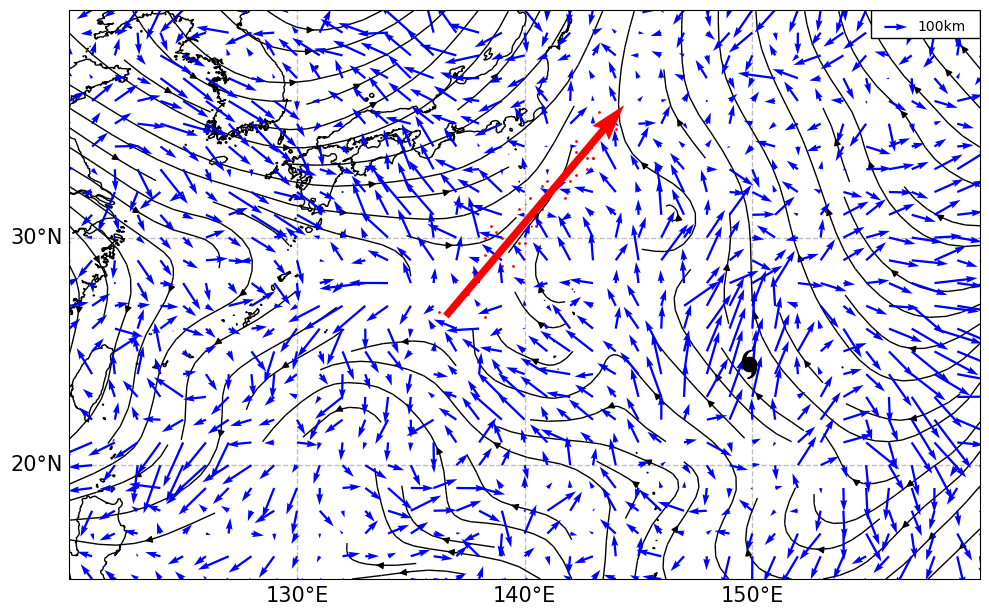

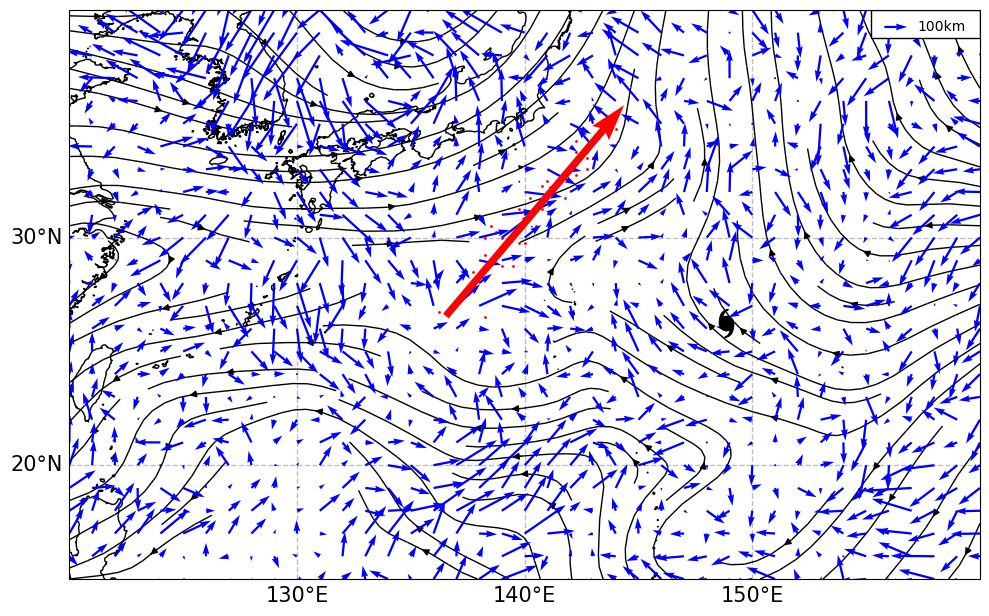

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# ESA Sensitivity Plot  (레퍼런스 Track_Steer_ESA.ipynb Cell 16의 스타일 완전 동일)
# 도메인: [120-160E, 15-40N]  |  분석 시간별 도형 하나씩
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.patches as patches
import tcmarkers

PLOT_LON = (120, 160)
PLOT_LAT  = (15, 40)

# Domain lon/lat for plotting (1-D, for scatter/quiver/streamplot)
_plot_lon_arr = lon_indices[lon_start:lon_end + 1]
_plot_lat_arr = lat_indices[lat_start:lat_end + 1]   # descending

_qs     = 4     # quiver stride (every 4th grid point)
U_scale = 100    # km  (레퍼런스와 동일)
# level = 'steer'
level = 500

# for h in ANALYSIS_HOURS:
for h in [12,24]:
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([*PLOT_LON, *PLOT_LAT], crs=ccrs.PlateCarree())
    ax.coastlines('10m', linewidth=1)
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = plt.FixedLocator(np.arange(120, 161, 10))
    gl.ylocator = plt.FixedLocator(np.arange(10, 41, 10))
    gl.xlabel_style = {'size': 15}
    gl.ylabel_style = {'size': 15}

    # ── Mid (analysis_hour) positions: yellowgreen s=1 ────────────────────────────────
    analysis_time = T0 + timedelta(hours=h)
    mid_lon = [ssv_dict[T0][ens][analysis_time]['lon']
               for ens in mems_tar if analysis_time in ssv_dict[T0].get(ens, {})]
    mid_lat = [ssv_dict[T0][ens][analysis_time]['lat']
               for ens in mems_tar if analysis_time in ssv_dict[T0].get(ens, {})]
    # ax.scatter(mid_lon, mid_lat, c='yellowgreen', s=1)
    plt.scatter(np.mean(mid_lon), np.mean(mid_lat), c='black', marker = tcmarkers.HU, s=100, zorder = 100)

    # ── Target (TARGET_HOUR) positions: red s=1 ─────────────────────────────────────
    ax.scatter(lons_tar, lats_tar, c='red', s=1)

    # ── Background: ensemble mean steering wind (streamlines, speed < 1 masking) ──────
    if level != 'steer':
        u_mean_h  = np.nanmean(u_steer_layers[h][:, STEER_LEVELS.index(level), :, :], axis=0)
        v_mean_h  = np.nanmean(v_steer_layers[h][:, STEER_LEVELS.index(level), :, :], axis=0)
    else:
        u_mean_h  = np.nanmean(u_steer[h], axis=0)
        v_mean_h  = np.nanmean(v_steer[h], axis=0)
    wind_speed = np.sqrt(u_mean_h**2 + v_mean_h**2)
    masked_u  = np.where(wind_speed < 1, np.nan, u_mean_h)
    masked_v  = np.where(wind_speed < 1, np.nan, v_mean_h)
    ax.streamplot(_plot_lon_arr, _plot_lat_arr[::-1],
                masked_u[::-1, :], masked_v[::-1, :],
                color='black', linewidth=1, density=1)

    # ── ESA: covariance quiver (blue) ──────────────────────────────────────────
    if not np.all(np.isnan(cov_u[h])):
        if level != 'steer':
            qui = ax.quiver(
                _plot_lon_arr[::_qs], _plot_lat_arr[::_qs],
                cov_u_layers[h][STEER_LEVELS.index(level),::_qs, ::_qs], cov_v_layers[h][STEER_LEVELS.index(level)][::_qs, ::_qs],
                scale=U_scale * 40, width=0.0025,
                transform=ccrs.PlateCarree(), color='blue', zorder=2
            )
        else:
            qui = ax.quiver(
                _plot_lon_arr[::_qs], _plot_lat_arr[::_qs],
                cov_u[h][::_qs, ::_qs], cov_v[h][::_qs, ::_qs],
                scale=U_scale * 40, width=0.0025,
                transform=ccrs.PlateCarree(), color='blue', zorder=2
            )
        rect = patches.Rectangle((0.88, 0.95), 0.12, 0.05,
                                  linewidth=1, edgecolor='black', facecolor='white',
                                  transform=ax.transAxes, zorder=2)
        ax.add_patch(rect)
        ax.quiverkey(qui, 0.92, 0.97, U=U_scale, label=f'{U_scale}km',
                     labelpos='E', coordinates='axes', zorder=10)

    # ── PCA 주축 화살표 (ax.quiver, 레퍼런스와 동일) ────────────────────────────
    explained_var = pca_tar.explained_variance_[0]
    spread_scale  = 1 * np.sqrt(explained_var) * 4
    v1      = pca_tar.components_[0]          # [dx_corrected, dy]
    v_lon   = v1[0] / cos_lat                 # 경도 보정 역산
    v_lat   = v1[1]
    origin_lon = np.mean(lons_tar)
    origin_lat = np.mean(lats_tar)
    ax.quiver(
        origin_lon - v_lon * spread_scale / 2,
        origin_lat - v_lat * spread_scale / 2,
        v_lon * spread_scale,
        v_lat * spread_scale,
        angles='xy', scale_units='xy', scale=1,
        color='red', width=0.008, headwidth=3,
        label='Principal Axis', zorder=30
    )

    # # ── Best-track at T0 ──────────────────────────────────────────────────────────────
    # _t0_idx = np.where(storm_time == T0)[0]
    # if len(_t0_idx):
    #     ax.plot(storm_lon[_t0_idx[0]], storm_lat[_t0_idx[0]],
    #             'k*', ms=12, transform=ccrs.PlateCarree(), zorder=6)

    # ax.set_title(f'T+{h}h  ESA Steering Wind Sensitivity  (N={N_tar})', fontsize=14)
    plt.tight_layout()
    plt.savefig(
        f'/data09/TC/TIGGE/ENS_field_data/ESA_sensitivity_{T0:%Y%m%d%H}_T{TARGET_HOUR}_A{h:02d}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()


Building NE-10 mean fields and computing PV...
Building SW-10 mean fields and computing PV...
Extracting ±3 degree swath cross-sections...


Text(0.5, 1.0, 'A: Diagonal (15°N,155°E → 40°N,142°E) - ±3° Swath Mean')

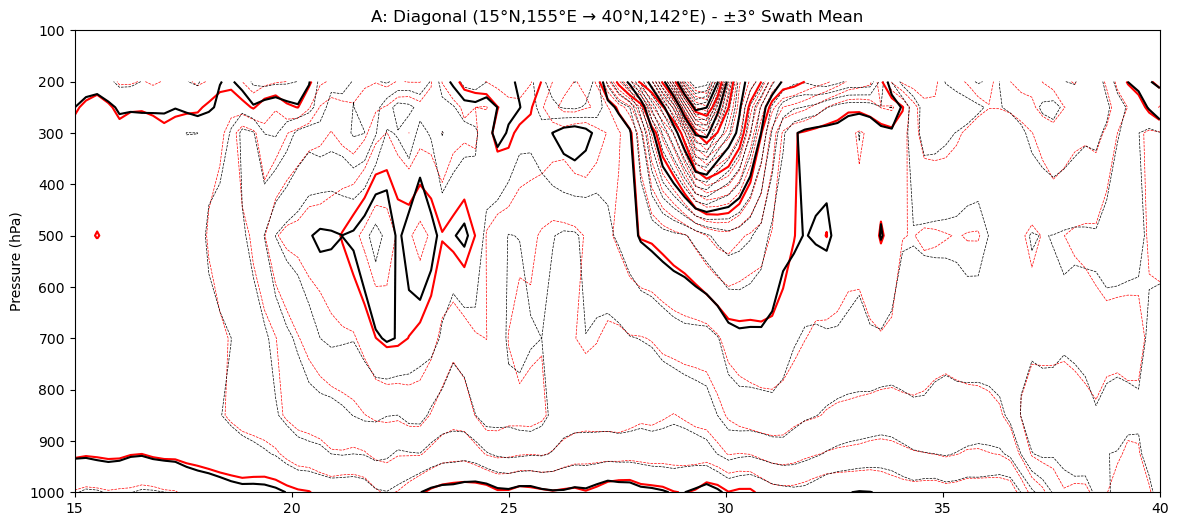

In [107]:
# ─────────────────────────────────────────────────────────────────────────────
# Top-10 / Bottom-10  Cross-Section PV + Wind (Refactored using Xarray & MetPy natively)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.units import units as munits
from metpy.interpolate import cross_section
from matplotlib.lines import Line2D

# ── Cross-section configuration ───────────────
XS_START = (15., 155.)   # (lat, lon)  diagonal start
XS_END   = (40., 142.)   # (lat, lon)  diagonal end
LON_BAND = (147.5, 152.5)   # longitude band for vertical cross-section B

# TIGGE available levels
_TIGGE_LEVS = [1000, 925, 850, 700, 500, 300, 250, 200]
analysis_hour = 0
XSEC_STEP_IDX = analysis_hour // 6

# ---------------------------------------------------------
# 1. 데이터 로드, 앙상블 평균 및 PV 계산 통합 함수
# ---------------------------------------------------------
def build_mean_metpy_ds(member_ids_group, is_cf_group=False):
    """
    1. Xarray를 사용하여 TIGGE 데이터를 로드하고 앙상블 평균을 계산합니다.
    2. Code 1 방식처럼 MetPy 호환 형식으로 좌표/단위를 파싱합니다.
    3. 온위(Theta)와 PV를 계산하여 단면 추출이 가능한 단일 MetPy Dataset으로 반환합니다.
    """
    member_ds_list = []

    for mid in member_ids_group:
        is_cf = (mid == CF_MEMBER_ID)
        z_path = CF_Z_PATH  if is_cf else Z_PATH
        u_path = CF_UV_PATH if is_cf else U_PATH
        v_path = CF_UV_PATH if is_cf else V_PATH
        t_path = CF_T_PATH  if is_cf else T_PATH

        with xr.open_dataset(z_path) as ds_zf, \
             xr.open_dataset(u_path) as ds_uf, \
             xr.open_dataset(v_path) as ds_vf, \
             xr.open_dataset(t_path) as ds_tf:

            # 1. 멤버 선택 (cf 모델은 date, 일반 앙상블은 number 기준)
            if is_cf:
                ds_z = ds_zf.sel(date=np.datetime64(T0.date()))
                ds_u = ds_uf.sel(date=np.datetime64(T0.date()))
                ds_v = ds_vf.sel(date=np.datetime64(T0.date()))
                ds_t = ds_tf.sel(date=np.datetime64(T0.date()))
            else:
                ds_z = ds_zf.sel(number=mid + 1)
                ds_u = ds_uf.sel(number=mid + 1)
                ds_v = ds_vf.sel(number=mid + 1)
                ds_t = ds_tf.sel(number=mid + 1)

            # 2. Xarray sel을 사용한 목표 도메인 및 레벨/시간 추출 
            # (MetPy가 인식하기 쉽도록 위도를 오름차순으로 강제 정렬합니다)
            lat_slice = slice(max(lat_start, lat_end), min(lat_start, lat_end))
            lon_slice = slice(min(lon_start, lon_end), max(lon_start, lon_end))

            ds_member = xr.Dataset({
                'u': ds_u['u'].isel(step=XSEC_STEP_IDX).sel(level=_TIGGE_LEVS),
                'v': ds_v['v'].isel(step=XSEC_STEP_IDX).sel(level=_TIGGE_LEVS),
                't': ds_t['t'].isel(step=XSEC_STEP_IDX).sel(level=_TIGGE_LEVS),
                'z': ds_z['gh'].isel(step=XSEC_STEP_IDX).sel(level=_TIGGE_LEVS)
            })
            
            # 위도, 경도 영역 자르기 & 위도 오름차순 정렬 (MetPy 호환성)
            ds_member = ds_member.sel(latitude=lat_slice, longitude=lon_slice).sortby('latitude')
            member_ds_list.append(ds_member)

    # 3. 앙상블 평균 계산 (xarray.concat 사용 - np.zeros 반복문 대체!)
    ds_mean = xr.concat(member_ds_list, dim='member').mean(dim='member')

    # 4. Code 1과 동일한 MetPy 호환 좌표 및 단위 부여
    lats = ds_mean['latitude'].values
    lons = ds_mean['longitude'].values
    levels = ds_mean['level'].values

    coords = {
        'pressure': ('pressure', levels, {'units': 'hPa', 'standard_name': 'air_pressure', 'axis': 'Z'}),
        'latitude': ('latitude', lats, {'units': 'degrees_north', 'standard_name': 'latitude', 'axis': 'Y'}),
        'longitude': ('longitude', lons, {'units': 'degrees_east', 'standard_name': 'longitude', 'axis': 'X'})
    }
    dims = ['pressure', 'latitude', 'longitude']

    P_da = xr.DataArray(levels, coords={'pressure': levels}, dims=['pressure'],
                        attrs={'units': 'hPa', 'standard_name': 'air_pressure', 'axis': 'Z'}).metpy.quantify()
    T_da = xr.DataArray(ds_mean['t'].values, coords=coords, dims=dims, attrs={'units': 'K'}).metpy.quantify()
    U_da = xr.DataArray(ds_mean['u'].values, coords=coords, dims=dims, attrs={'units': 'm/s'}).metpy.quantify()
    V_da = xr.DataArray(ds_mean['v'].values, coords=coords, dims=dims, attrs={'units': 'm/s'}).metpy.quantify()

    # 5. 온위(Theta) 및 PV 계산
    theta_da = mpcalc.potential_temperature(P_da, T_da)
    pv_da = mpcalc.potential_vorticity_baroclinic(theta_da, P_da, U_da, V_da)

    # 6. 모든 변수를 병합한 최종 MetPy Dataset 생성
    ds_3d = xr.Dataset(
        {
            "pv": (dims, (pv_da * 1e6).metpy.magnitude),
            "theta": (dims, theta_da.metpy.magnitude),
            "u": (dims, ds_mean['u'].values, {'units': 'm/s'}),
            "v": (dims, ds_mean['v'].values, {'units': 'm/s'}),
            "z": (dims, ds_mean['z'].values, {'units': 'm'})
        },
        coords=coords
    )

    # CRS 지정 및 CF 파싱 후 quantify 적용 (이제 cross_section 준비 완료)
    ds_3d = ds_3d.metpy.assign_crs(grid_mapping_name='latitude_longitude')
    ds_3d = ds_3d.metpy.parse_cf().metpy.quantify()

    return ds_3d


# ---------------------------------------------------------
# 2. 데이터 처리 및 단면 추출
# ---------------------------------------------------------
print("Building NE-10 mean fields and computing PV...")
ds_ne_ready = build_mean_metpy_ds(top10_ids)

print("Building SW-10 mean fields and computing PV...")
ds_sw_ready = build_mean_metpy_ds(bot10_ids)

# ★ 새로 추가: 좌우 범위를 주어 여러 단면을 추출하고 평균내는 헬퍼 함수
def get_swath_cross_section(ds, start_pt, end_pt, width_deg=6.0, num_lines=13, steps=100):
    """
    단일 선이 아닌 width_deg(총 폭)만큼 오프셋을 주어 단면을 추출한 뒤 평균을 반환합니다.
    """
    offsets = np.linspace(-width_deg/2, width_deg/2, num_lines)
    pv_lines, theta_lines = [], []
    
    for off in offsets:
        # 기존 코드처럼 경도 방향(인덱스 1)에 오프셋을 더합니다.
        start_pt_off = (start_pt[0], start_pt[1] + off)
        end_pt_off = (end_pt[0], end_pt[1] + off)
        
        # steps를 고정해야 배열 형태가 동일해져서 np.mean을 할 수 있습니다.
        cross = cross_section(ds, start=start_pt_off, end=end_pt_off, steps=steps)
        
        pv_lines.append(cross['pv'].values)
        theta_lines.append(cross['theta'].values)
        
        # 중심선(off=0)일 때의 위/경도 좌표를 X축 시각화용으로 저장
        if off == 0.0:
            lats_cross = cross['latitude'].values
            lons_cross = cross['longitude'].values
            
    # 앙상블 단면 평균 산출
    pv_mean = np.mean(pv_lines, axis=0)
    theta_mean = np.mean(theta_lines, axis=0)
    
    return pv_mean, theta_mean, lats_cross, lons_cross

print("Extracting ±3 degree swath cross-sections...")
# 단일 cross_section() 대신 우리가 만든 swath 함수를 사용합니다.
pv_ne_swath, theta_ne_swath, lat_cross, lon_cross = get_swath_cross_section(ds_ne_ready, XS_START, XS_END)
pv_sw_swath, theta_sw_swath, _, _ = get_swath_cross_section(ds_sw_ready, XS_START, XS_END)

# ---------------------------------------------------------
# 3. 플로팅 (Plot: 2 panels)
# ---------------------------------------------------------
_lats_asc = ds_ne_ready['latitude'].values
_lons_asc = ds_ne_ready['longitude'].values
_levs_arr = ds_ne_ready['pressure'].values

fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharey=True)

# ── Panel A: Diagonal cross-section ───────────────────────────────────────────
clevs_pv = np.linspace(0, 3, 31)

# 추출한 swath 평균 데이터(pv_ne_swath 등)와 중심선 위도(lat_cross)를 사용하여 플로팅합니다.
cs_ne = ax.contour(lat_cross, _levs_arr, pv_ne_swath,
                     levels=clevs_pv, colors='red', linewidths=0.5, linestyles='--')
cs_sw = ax.contour(lat_cross, _levs_arr, pv_sw_swath,
                     levels=clevs_pv, colors='black', linewidths=0.5, linestyles='--')

ax.contour(lat_cross, _levs_arr, pv_ne_swath, levels=np.arange(0.1, 3.1, 0.5),
           colors='red',  linestyles='-', linewidths=1.5)
ax.contour(lat_cross, _levs_arr, pv_sw_swath, levels=np.arange(0.1, 3.1, 0.5),
           colors='black', linestyles='-', linewidths=1.5)

ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)')
ax.set_title('A: Diagonal (15°N,155°E → 40°N,142°E) - ±3° Swath Mean')

# # ── Panel B: Longitude band cross-section ─────────────────────────────────────
# _lon_mask = (_lons_asc >= LON_BAND[0]) & (_lons_asc <= LON_BAND[1])

# # Xarray의 강점을 활용하여 깔끔하게 평균 추출
# pv_top_B    = ds_ne_ready['pv'].values[:, :, _lon_mask].mean(axis=2)
# pv_bot_B    = ds_sw_ready['pv'].values[:, :, _lon_mask].mean(axis=2)
# theta_top_B = ds_ne_ready['theta'].values[:, :, _lon_mask].mean(axis=2)
# theta_bot_B = ds_sw_ready['theta'].values[:, :, _lon_mask].mean(axis=2)


# plt.suptitle(f'PV Cross-Section  |  T+{TARGET_HOUR}h  |  Top-10 (red) vs Bot-10 (blue)\n'
#              f'Init: {T0:%Y-%m-%d %H}Z  (θ isentropes: 280–400 K, 5 K)',
#              fontsize=11)
# plt.tight_layout()
# plt.savefig(f'/data09/TC/TIGGE/ENS_field_data/PV_xsec_{T0:%Y%m%d%H}_T{TARGET_HOUR}.png',
#             dpi=150, bbox_inches='tight')
# plt.show()
# print("Cross-section PV plot saved.")

<xarray.DataArray 'step' (step: 41)> Size: 328B
array([              0,  21600000000000,  43200000000000,  64800000000000,
        86400000000000, 108000000000000, 129600000000000, 151200000000000,
       172800000000000, 194400000000000, 216000000000000, 237600000000000,
       259200000000000, 280800000000000, 302400000000000, 324000000000000,
       345600000000000, 367200000000000, 388800000000000, 410400000000000,
       432000000000000, 453600000000000, 475200000000000, 496800000000000,
       518400000000000, 540000000000000, 561600000000000, 583200000000000,
       604800000000000, 626400000000000, 648000000000000, 669600000000000,
       691200000000000, 712800000000000, 734400000000000, 756000000000000,
       777600000000000, 799200000000000, 820800000000000, 842400000000000,
       864000000000000], dtype='timedelta64[ns]')
Coordinates:
  * step     (step) timedelta64[ns] 328B 0 days 00:00:00 ... 10 days 00:00:00
    date     datetime64[ns] 8B 2022-08-27
Attributes:
    lon

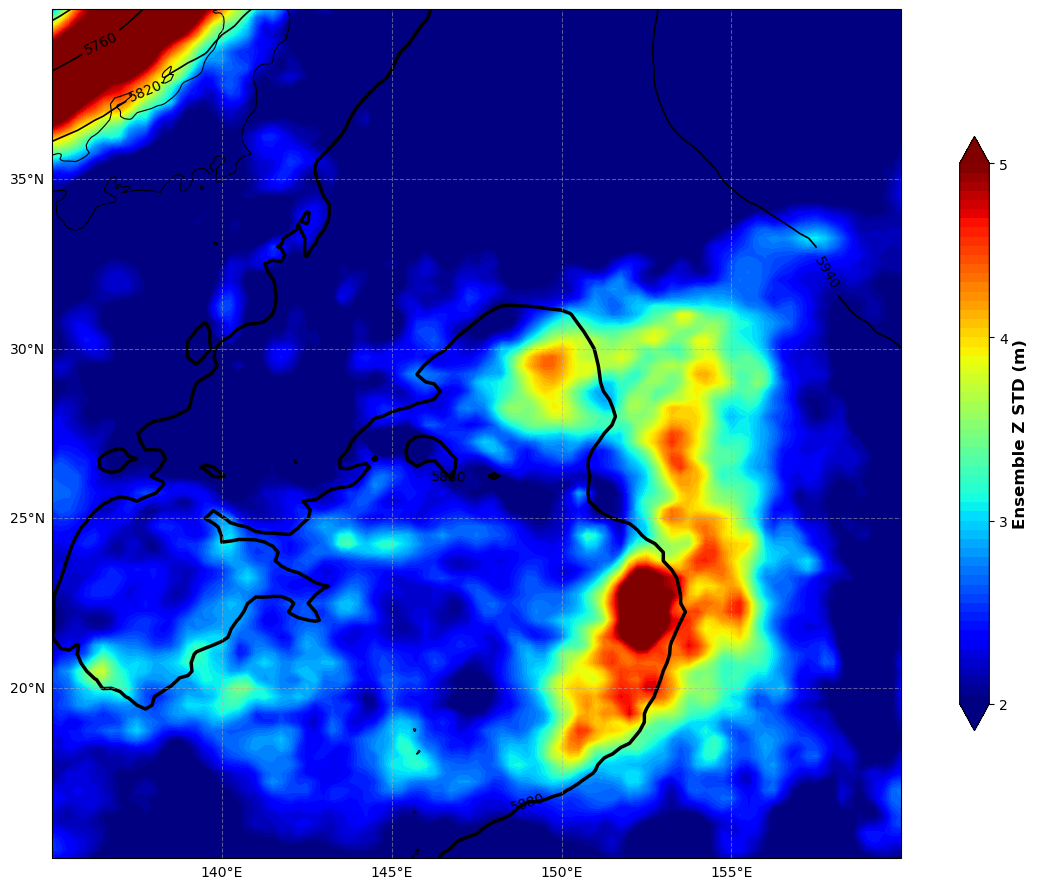

In [38]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def plot_ensemble_z500_variability(member_ids, title_suffix="Top-10"):
    """
    지정된 앙상블 멤버들의 500hPa 지점고도 평균과 표준편차를 그립니다.
    """
    member_z_list = []

    # 1. 데이터 수집 (기존 로직 활용)
    for mid in member_ids:
        is_cf = (mid == CF_MEMBER_ID)
        z_path = CF_Z_PATH if is_cf else Z_PATH
        
        with xr.open_dataset(z_path) as ds:
            if is_cf:
                # Control Forecast
                z_member = ds['gh'].sel(date=np.datetime64(T0.date()), 
                                        level=500).isel(step=2)
                z_what = ds['gh'].sel(date=np.datetime64(T0.date()))
                print(z_what['step'])
                print(z_what['level'])
                
            else:
                # Ensemble Members
                z_member = ds['gh'].sel(number=mid + 1, 
                                        level=500).isel(step=0)

            # --- 수정 포인트: 불필요한 좌표 제거 ---
            # number나 date 좌표가 남아있으면 합칠 때 충돌하므로 제거합니다.
            if 'number' in z_member.coords:
                z_member = z_member.drop_vars('number')
            if 'date' in z_member.coords:
                z_member = z_member.drop_vars('date')
            # --------------------------------------
            
            # 위경도 범위 자르기 (분석 영역에 맞게 조절)
            z_member = z_member.sel(latitude=slice(40, 15), longitude=slice(135, 160))
            member_z_list.append(z_member)

    # 2. 통계량 계산 (평균 및 표준편차)
    ds_all = xr.concat(member_z_list, dim='member')
    z_mean = ds_all.mean(dim='member')
    z_std  = ds_all.std(dim='member')

    # 3. 시각화 설정
    fig = plt.figure(figsize=(12, 9))
    proj = ccrs.PlateCarree()
    ax = plt.axes(projection=proj)

    # 지도 기본 요소 추가
    ax.set_extent([135, 160, 15, 40], crs=proj)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    # --- (A) Ensemble Variability (Shading: Standard Deviation) ---
    # 변동성이 클수록 예측 불확실성이 높음을 의미함
    std_levels = np.arange(2, 5, 0.05)  # 0m ~ 10m, 1m 간격
    cmap = plt.get_cmap('jet')
    norm = BoundaryNorm(std_levels, ncolors=cmap.N, clip=False)
    
    cf = ax.contourf(z_std.longitude, z_std.latitude, z_std,
                     levels=std_levels, cmap=cmap, norm=norm, 
                     extend='both', transform=proj)

    # --- (B) Ensemble Mean (Contour: Geopotential Height) ---
    # 5880gpm 선은 아열대 고기압의 가장자리를 나타내는 중요한 지표
    z_levels = np.arange(5400, 6000, 60) # 60gpm 간격
    cs = ax.contour(z_mean.longitude, z_mean.latitude, z_mean,
                    levels=z_levels, colors='black', linewidths=1.2, transform=proj)
    ax.clabel(cs, inline=True, fontsize=10, fmt='%1.0f')
    
    # 5880 line 강조 (태풍 조향에 핵심)
    ax.contour(z_mean.longitude, z_mean.latitude, z_mean,
               levels=[5880], colors='black', linewidths=2.5, transform=proj)

    # --- (C) 마무리 설정 ---
    cbar = plt.colorbar(cf, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
    cbar.set_label('Ensemble Z STD (m)', fontsize=12, fontweight='bold')
    cbar.set_ticks(np.arange(2, 5.1, 1))
    
    # plt.title(f'500hPa Z Mean & Variability\nTarget: T+{12}h ({title_suffix})', 
    #           fontsize=16, fontweight='bold', pad=15)
    
    # 격자선 추가
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.tight_layout()
    plt.show()

# 실행 예시
plot_ensemble_z500_variability(mems_sort, title_suffix="Survived members")

In [10]:
mems_sort

array([36, 32, 11, 45, 22, 24,  1,  7, 39, 49, 27, 38, 30, 21, 26, 41, 17,
       23, 33,  9, 25, 50, 10, 48, 29,  3, 28, 13, 44, 31, 46, 43, 34])

{0: 57.5, 6: 54.6, 12: 54.2, 18: 88.7, 24: 78.4, 30: 94.1, 36: 111.5, 42: 128.5, 48: 147.3, 54: 175.9, 60: 213.3, 66: 265.7, 72: 317.5, 78: 406.4, 84: 496.0, 90: 593.4, 96: 702.3, 102: 866.2, 108: 968.7, 114: 1064.6, 120: 1198.4}
{0: 37, 6: 38, 12: 44, 18: 47, 24: 48, 30: 49, 36: 49, 42: 49, 48: 48, 54: 46, 60: 44, 66: 39, 72: 35, 78: 29, 84: 27, 90: 22, 96: 19, 102: 16, 108: 15, 114: 13, 120: 11}
51/51 ensembles predicted the track.


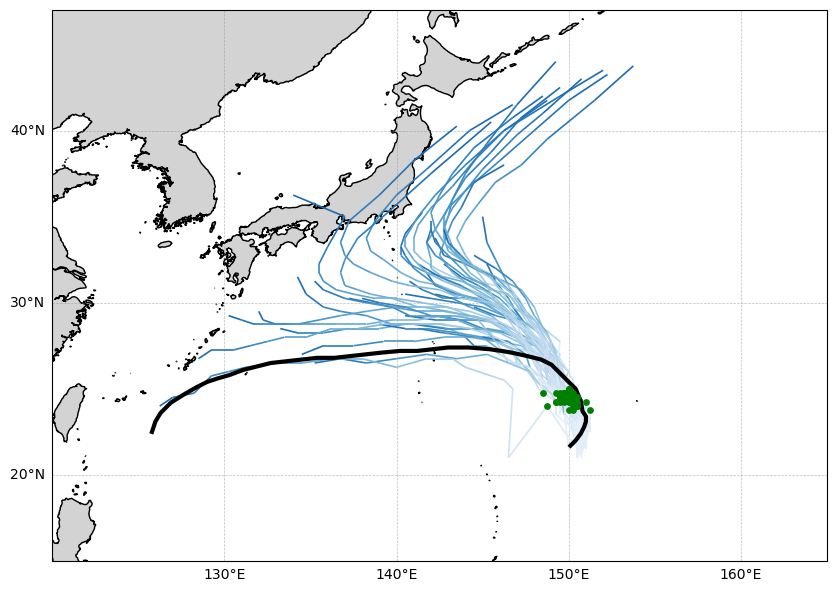

(0.0, 60.0)

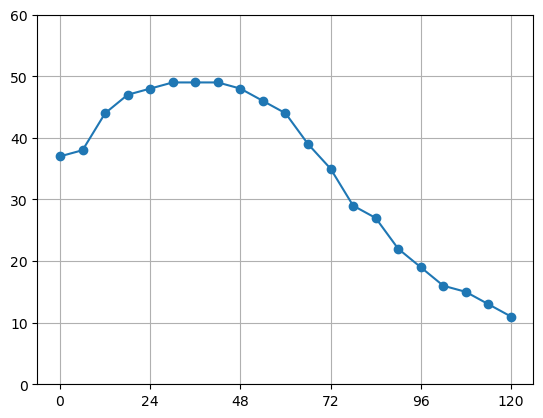

In [12]:
def plot_ens_tracks(lons, lats, ax, cmap, zorder = 0):

    x = np.array(lons)
    y = np.array(lats)

    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    if len(x_clean) < 2:
        return

    points = np.array([x_clean, y_clean]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    t = np.linspace(0, 1, len(x_clean))

    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1), zorder = zorder)
    lc.set_array(t)
    lc.set_linewidth(1.2)

    ax.add_collection(lc)


min_position = ssv_dict[T0]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
plot_extent = [120, 165, 15, 47]
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines("10m")
full_blues = plt.get_cmap('Blues')
new_colors_blue = full_blues(np.linspace(0.1, 0.8, 256))
blue_cmap = mcolors.LinearSegmentedColormap.from_list('Blues_truncated', new_colors_blue)
ax.plot(storm_lon[:41], storm_lat[:41], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=3)

num = 0
for ens in range(MAX_MEMBERS):  
    lons = [pos['lon'] for _,pos in min_position[ens].items()]
    lats = [pos['lat'] for _,pos in min_position[ens].items()]
    plot_ens_tracks(lons, lats, ax, cmap = blue_cmap, zorder = 8)
    # max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
    # pred_times = [pos for pos,_ in min_position[ens].items()]
    num += 1 if len(lons)>0 else 0
    # lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
# cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)


ens_spread_dict = {}
ens_error_dict = {}
ens_num_dict = {}

mid_pos = []
for t in range(0, 121, 6):
    snap_time = T0 + timedelta(hours = t)
    tar_pos = []
    for ens, single_data in min_position.items():
        snap_data = min_position[ens].get(T0+timedelta(hours=t), None)

        if snap_data:
            tar_pos.append([snap_data['lon'], snap_data['lat']])
            if t == 12:
                mid_pos.append([snap_data['lon'], snap_data['lat']])

    if len(tar_pos) <= 1:
        continue
    else:
        tar_pos = np.array(tar_pos)

    snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
    
    # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

    corr_pos_tar = np.copy(tar_pos)
    corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
    pca_tar = PCA(n_components=1)
    pca_tar.fit(corr_pos_tar)
    pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])
    projection = pca_tar.transform(corr_pos_tar)[:, 0]  # 주축에 투영된 데이터 (1차원)
    distances_tar = (projection - np.mean(projection)) * 111
    ens_spread_dict[t] = np.std(distances_tar, ddof = 1).round(1)
    # ens_error_dict[t] = haversine_distance(snap_lon, snap_lat, avg_lon, avg_lat).round(1)
    ens_num_dict[t] = len(distances_tar)

print(ens_spread_dict)
# print(ens_error_dict)
print(ens_num_dict)

ax.scatter(np.array(mid_pos)[:,0], np.array(mid_pos)[:,1], color = 'green', zorder = 12, s=15)

print(f"{num}/{MAX_MEMBERS} ensembles predicted the track.")
plt.show()

plt.plot(ens_num_dict.keys(), list(ens_num_dict.values()), marker='o')
plt.grid()
plt.xticks(range(0, 121, 24))
plt.ylim(0,60)